In [3]:
# ================================================================
# PART 2 — CELL 1: Setup (Manufacturing Defect CNN)
# Dataset: images/ folder with subfolders: normal/ scratch/ dent/ stain/
# ================================================================
import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')
os.makedirs('results',exist_ok=True)
os.makedirs('sample_predictions',exist_ok=True)

from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
print(f"TensorFlow {tf.__version__}  ✅")

# ⚠️  UPDATE: point to the images/ subfolder (which contains the 4 class folders)
DATA_DIR = '/content/drive/MyDrive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images'

print("Dataset check:")
for cls in sorted(os.listdir(DATA_DIR)):
    p=os.path.join(DATA_DIR,cls)
    if os.path.isdir(p):
        n=len([f for f in os.listdir(p) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"  {cls}: {n} images")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow 2.20.0  ✅
Dataset check:
  dent: 120 images
  normal: 120 images
  scratch: 120 images
  stain: 120 images


Classes (4): ['dent', 'normal', 'scratch', 'stain']

===== TASK 1: PROBLEM IDENTIFICATION =====
Problem type: IMAGE CLASSIFICATION (4 classes)
Reason: Each image folder represents one product surface condition.
The CNN learns visual patterns distinguishing normal surfaces from
three defect types: scratch (linear marks), dent (circular marks),
stain (coloured patches). This maps directly to automated visual
quality inspection on manufacturing production lines.

===== TASK 2: DATASET EXPLORATION =====
  dent: 120 images
  normal: 120 images
  scratch: 120 images
  stain: 120 images
Total: 480 images
Classes roughly balanced ✅
Original image size: (96, 96) px  (will be resized to (128, 128))


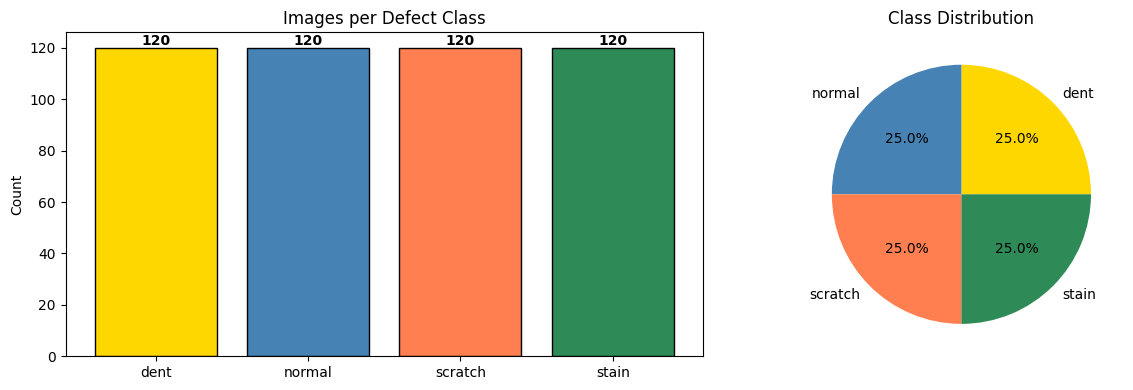

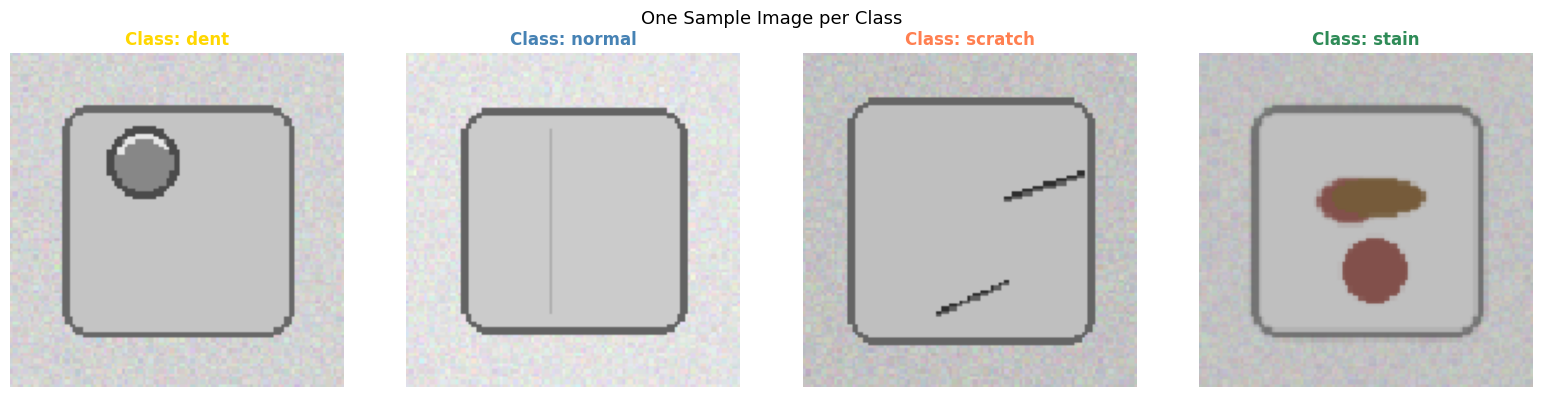


===== TASK 3: IMAGE PREPROCESSING =====
• Resizing all images to (128, 128) (standardises input dimensions)
• Normalising pixel values to [0,1] by dividing by 255
• Augmenting training images to improve generalisation
• 80/20 train-validation split
Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.
Class mapping: {'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}
Train batches: 12  |  Val batches: 3

===== TASK 4: CNN MODEL CREATION =====


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1a (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv2D)                 │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3a (Conv2D)                 │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3b (Conv2D)                 │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,678,820 (33.11 MB)

 Trainable params: 8,677,860 (33.10 MB)

 Non-trainable params: 960 (3.75 KB)

✅ CNN model built!

===== TASK 5: TRAINING AND EVALUATION (may take 5-10 min) =====
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 83s 6s/step - accuracy: 0.3750 - loss: 1.7673 - val_accuracy: 0.2500 - val_loss: 1.4918
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 68s 5s/step - accuracy: 0.4740 - loss: 1.4009 - val_accuracy: 0.2500 - val_loss: 1.7361
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 64s 5s/step - accuracy: 0.5026 - loss: 1.1981 - val_accuracy: 0.2500 - val_loss: 1.8451
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 69s 6s/step - accuracy: 0.5964 - loss: 0.9491 - val_accuracy: 0.2500 - val_loss: 2.4156
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 64s 5s/step - accuracy: 0.7344 - loss: 0.6139 - val_accuracy: 0.2500 - val_loss: 3.3423
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 93s 6s/step - accuracy: 0.7604 - loss: 0.5816 - val_accuracy: 0.2500 - val_loss: 3.5277
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 63s 5s/step - accuracy: 0.7708 - loss: 0.4861 - val_accuracy: 0.2500 - val_loss: 4.1346
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━

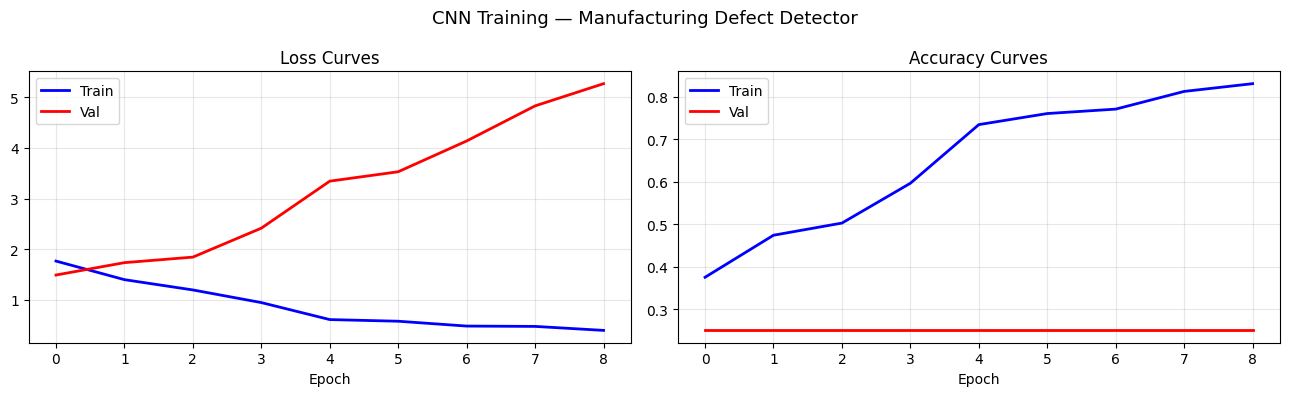

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step

Validation Accuracy: 0.2500 (25.00%)
              precision    recall  f1-score   support

        dent       0.00      0.00      0.00        24
      normal       0.25      1.00      0.40        24
     scratch       0.00      0.00      0.00        24
       stain       0.00      0.00      0.00        24

    accuracy                           0.25        96
   macro avg       0.06      0.25      0.10        96
weighted avg       0.06      0.25      0.10        96



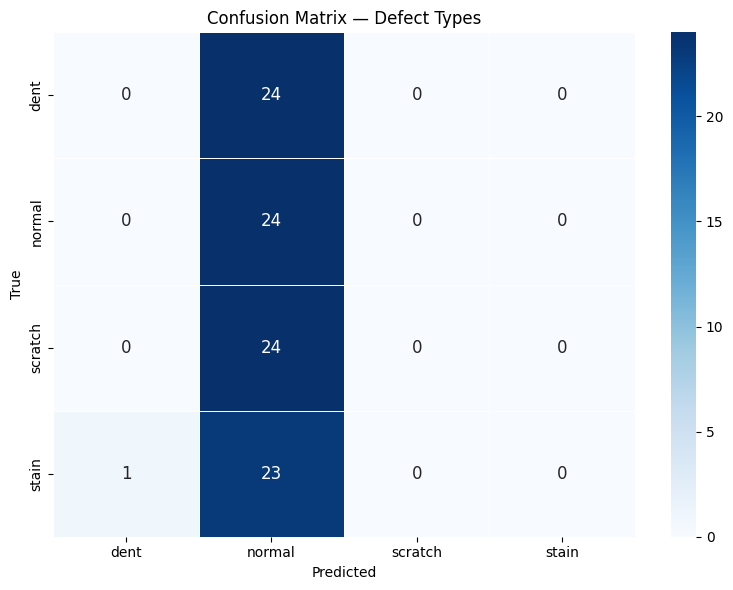

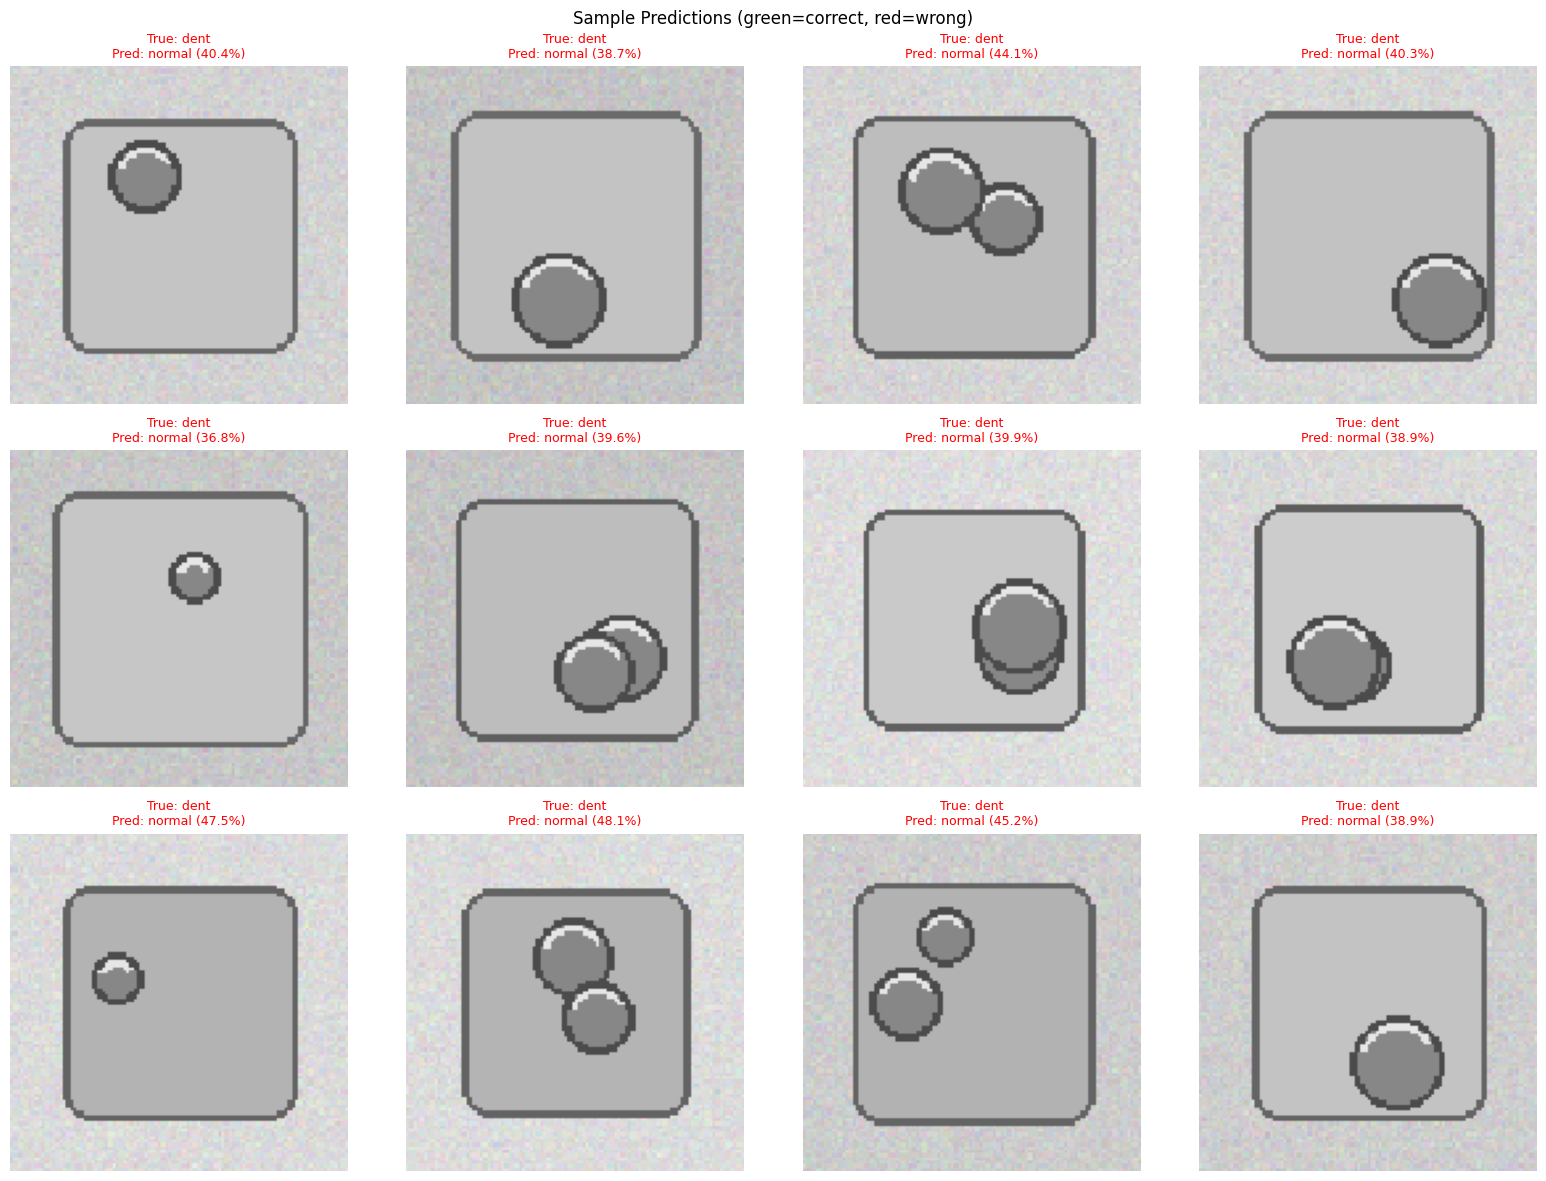


===== TASK 6: CNN CONCEPT EXPLANATION =====
Convolution: A small filter (kernel) slides over the image computing dot
products at each position. It detects local patterns — edges for scratch
lines, circles for dents, colour gradients for stains.

Pooling: MaxPooling reduces spatial size (e.g. 128x128 → 64x64), keeping
the most prominent features. This makes the model invariant to small
shifts — a scratch slightly off-centre is still recognised as a scratch.

ReLU: Most pixels after convolution are near zero (no pattern). ReLU
sets negatives to zero, keeping only activations where a pattern was
detected. It avoids the vanishing gradient problem of sigmoid/tanh.

CNNs vs Feed-Forward: A 128x128 RGB image has 49,152 inputs. A dense
layer connecting all pixels ignores spatial structure and needs millions
of parameters. CNNs share filter weights across positions — far fewer
parameters, much better at capturing spatial patterns.

===== TASK 7: BUSINESS USE CASE — MANUFACTURING =====
Domain: 

In [4]:
# ================================================================
# PART 2 — CELL 2: Full CNN Notebook (all 7 tasks)
# ================================================================

CLASSES  = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR,d))])
N_CLS    = len(CLASSES)
IMG_SIZE = (128,128)
BATCH    = 32
print(f"Classes ({N_CLS}): {CLASSES}")

# ── TASK 1: PROBLEM IDENTIFICATION ───────────────────────────
print("\n===== TASK 1: PROBLEM IDENTIFICATION =====")
print("Problem type: IMAGE CLASSIFICATION (4 classes)")
print("Reason: Each image folder represents one product surface condition.")
print("The CNN learns visual patterns distinguishing normal surfaces from")
print("three defect types: scratch (linear marks), dent (circular marks),")
print("stain (coloured patches). This maps directly to automated visual")
print("quality inspection on manufacturing production lines.")

# ── TASK 2: DATASET EXPLORATION ──────────────────────────────
print("\n===== TASK 2: DATASET EXPLORATION =====")
class_counts={}
for cls in CLASSES:
    fs=[f for f in os.listdir(os.path.join(DATA_DIR,cls))
        if f.lower().endswith(('.jpg','.jpeg','.png'))]
    class_counts[cls]=len(fs)
    print(f"  {cls}: {len(fs)} images")
total=sum(class_counts.values())
print(f"Total: {total} images")

# Check imbalance
mx,mn=max(class_counts.values()),min(class_counts.values())
if mx/mn>1.5: print("⚠️  Imbalance detected — augmentation will help")
else: print("Classes roughly balanced ✅")

# Sample image dimensions
for cls in CLASSES:
    fs=[f for f in os.listdir(os.path.join(DATA_DIR,cls)) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if fs:
        img=load_img(os.path.join(DATA_DIR,cls,fs[0]))
        print(f"Original image size: {img.size} px  (will be resized to {IMG_SIZE})")
        break

# Distribution plot
colors={'normal':'steelblue','scratch':'coral','dent':'gold','stain':'seagreen'}
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].bar(class_counts.keys(),class_counts.values(),
            color=[colors.get(c,'gray') for c in class_counts],edgecolor='black')
axes[0].set_title('Images per Defect Class'); axes[0].set_ylabel('Count')
for i,(c,n) in enumerate(class_counts.items()):
    axes[0].text(i,n+1,str(n),ha='center',fontweight='bold')
axes[1].pie(class_counts.values(),labels=class_counts.keys(),autopct='%1.1f%%',
            colors=[colors.get(c,'gray') for c in class_counts])
axes[1].set_title('Class Distribution')
plt.tight_layout(); plt.savefig('results/class_distribution.png',dpi=150); plt.show()

# Sample images from all 4 classes
fig,axes=plt.subplots(1,4,figsize=(16,4))
for ax,cls in zip(axes,CLASSES):
    p=os.path.join(DATA_DIR,cls)
    fs=[f for f in os.listdir(p) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if fs:
        ax.imshow(load_img(os.path.join(p,fs[0]),target_size=(128,128)))
        ax.set_title(f'Class: {cls}',fontweight='bold',
                     color=colors.get(cls,'black')); ax.axis('off')
plt.suptitle('One Sample Image per Class',fontsize=13)
plt.tight_layout(); plt.savefig('results/sample_images_per_class.png',dpi=150); plt.show()

# ── TASK 3: IMAGE PREPROCESSING ──────────────────────────────
print("\n===== TASK 3: IMAGE PREPROCESSING =====")
print(f"• Resizing all images to {IMG_SIZE} (standardises input dimensions)")
print("• Normalising pixel values to [0,1] by dividing by 255")
print("• Augmenting training images to improve generalisation")
print("• 80/20 train-validation split")

train_dg=ImageDataGenerator(rescale=1./255,rotation_range=20,
    width_shift_range=.15,height_shift_range=.15,horizontal_flip=True,
    zoom_range=.15,brightness_range=[.8,1.2],validation_split=.2)
val_dg=ImageDataGenerator(rescale=1./255,validation_split=.2)

train_gen=train_dg.flow_from_directory(DATA_DIR,target_size=IMG_SIZE,
    batch_size=BATCH,class_mode='categorical',subset='training',seed=42)
val_gen=val_dg.flow_from_directory(DATA_DIR,target_size=IMG_SIZE,
    batch_size=BATCH,class_mode='categorical',subset='validation',shuffle=False,seed=42)

cls_names=list(train_gen.class_indices.keys())
print(f"Class mapping: {train_gen.class_indices}")
print(f"Train batches: {len(train_gen)}  |  Val batches: {len(val_gen)}")

# ── TASK 4: CNN MODEL ────────────────────────────────────────
print("\n===== TASK 4: CNN MODEL CREATION =====")
model=keras.Sequential([
    # Block 1: edges, lines → key for scratch/dent boundaries
    layers.Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(*IMG_SIZE,3),name='conv1a'),
    layers.BatchNormalization(),
    layers.Conv2D(32,(3,3),activation='relu',padding='same',name='conv1b'),
    layers.MaxPooling2D(2,2,name='pool1'),layers.Dropout(.25),

    # Block 2: textures, shapes → dent circles, scratch lines
    layers.Conv2D(64,(3,3),activation='relu',padding='same',name='conv2a'),
    layers.BatchNormalization(),
    layers.Conv2D(64,(3,3),activation='relu',padding='same',name='conv2b'),
    layers.MaxPooling2D(2,2,name='pool2'),layers.Dropout(.25),

    # Block 3: complex patterns → stain colour blobs, combined features
    layers.Conv2D(128,(3,3),activation='relu',padding='same',name='conv3a'),
    layers.BatchNormalization(),
    layers.Conv2D(128,(3,3),activation='relu',padding='same',name='conv3b'),
    layers.MaxPooling2D(2,2,name='pool3'),layers.Dropout(.25),

    # Classifier head
    layers.Flatten(),
    layers.Dense(256,activation='relu',name='dense1'),
    layers.BatchNormalization(),layers.Dropout(.5),
    layers.Dense(N_CLS,activation='softmax',name='output')   # 4 defect classes
])
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()
print("✅ CNN model built!")

# ── TASK 5: TRAIN AND EVALUATE ───────────────────────────────
print("\n===== TASK 5: TRAINING AND EVALUATION (may take 5-10 min) =====")
hist=model.fit(train_gen,epochs=30,validation_data=val_gen,
               callbacks=[EarlyStopping(patience=8,restore_best_weights=True,verbose=1)],verbose=1)

fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].plot(hist.history['loss'],label='Train',color='blue',lw=2)
axes[0].plot(hist.history['val_loss'],label='Val',color='red',lw=2)
axes[0].set_title('Loss Curves'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True,alpha=.3)
axes[1].plot(hist.history['accuracy'],label='Train',color='blue',lw=2)
axes[1].plot(hist.history['val_accuracy'],label='Val',color='red',lw=2)
axes[1].set_title('Accuracy Curves'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True,alpha=.3)
plt.suptitle('CNN Training — Manufacturing Defect Detector',fontsize=13)
plt.tight_layout(); plt.savefig('results/accuracy_loss_curves.png',dpi=150); plt.show()

val_gen.reset()
yp=model.predict(val_gen,verbose=1); yp_cls=np.argmax(yp,1); yt=val_gen.classes
acc=accuracy_score(yt,yp_cls)
print(f"\nValidation Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(classification_report(yt,yp_cls,target_names=cls_names))

cm=confusion_matrix(yt,yp_cls)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',linewidths=.5,
            xticklabels=cls_names,yticklabels=cls_names,annot_kws={'size':12})
plt.title('Confusion Matrix — Defect Types'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.savefig('results/confusion_matrix.png',dpi=150); plt.show()

val_gen.reset(); imgs,lbls=next(val_gen); preds=model.predict(imgs[:12],verbose=0)
fig,axes=plt.subplots(3,4,figsize=(16,12))
for i,ax in enumerate(axes.flat):
    if i<len(imgs):
        ax.imshow(imgs[i])
        tl=cls_names[np.argmax(lbls[i])]; pl=cls_names[np.argmax(preds[i])]
        conf=np.max(preds[i])*100; ok=tl==pl
        ax.set_title(f"True: {tl}\nPred: {pl} ({conf:.1f}%)",
                     color='green' if ok else 'red',fontsize=9)
        ax.axis('off')
plt.suptitle('Sample Predictions (green=correct, red=wrong)'); plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png',dpi=150); plt.show()

# ── TASK 6 & 7: CONCEPTS + BUSINESS ─────────────────────────
print("""
===== TASK 6: CNN CONCEPT EXPLANATION =====
Convolution: A small filter (kernel) slides over the image computing dot
products at each position. It detects local patterns — edges for scratch
lines, circles for dents, colour gradients for stains.

Pooling: MaxPooling reduces spatial size (e.g. 128x128 → 64x64), keeping
the most prominent features. This makes the model invariant to small
shifts — a scratch slightly off-centre is still recognised as a scratch.

ReLU: Most pixels after convolution are near zero (no pattern). ReLU
sets negatives to zero, keeping only activations where a pattern was
detected. It avoids the vanishing gradient problem of sigmoid/tanh.

CNNs vs Feed-Forward: A 128x128 RGB image has 49,152 inputs. A dense
layer connecting all pixels ignores spatial structure and needs millions
of parameters. CNNs share filter weights across positions — far fewer
parameters, much better at capturing spatial patterns.

===== TASK 7: BUSINESS USE CASE — MANUFACTURING =====
Domain: Automotive / Electronics Manufacturing Quality Inspection
Current process: Human inspectors examine products on conveyor belts.
One inspector checks ~300 parts/hour; fatigue causes missed defects.
AI solution: Camera above conveyor captures images; CNN classifies in
<100ms per image → 10,000+ parts/hour, 24/7, consistent accuracy.
Impact: 60-80% reduction in defective products reaching customers,
lower warranty costs, reduced inspection labour cost.
""")

In [5]:
import shutil
from google.colab import files
shutil.make_archive('part2_results','zip','results')
files.download('part2_results.zip')
shutil.make_archive('part2_preds','zip','sample_predictions')
files.download('part2_preds.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Part 2: Computer Vision Problem Formulation and CNN Prototype

## Dataset
Source: https://drive.google.com/drive/folders/1akV6po4Nrgkc3yQrJkzA6cJIV-wBvUYs

## Problem Type: Image Classification
The dataset contains labelled image folders. Each image is assigned to one
category. This is a supervised multi-class classification problem.

## CNN Concept Explanations

**What is convolution?**
A small filter (kernel) slides over the image computing dot products at each
position, detecting local patterns such as edges and textures. Different
filters learn different features automatically.

**Why is pooling used?**
MaxPooling reduces spatial dimensions, making the model robust to small
position shifts (translation invariance) and cutting computation.

**Why ReLU in CNNs?**
ReLU (max(0,x)) introduces non-linearity without the vanishing gradient
problem of sigmoid/tanh. It is fast and keeps gradients flowing.

**CNNs vs Feed-Forward Networks**
Regular networks treat every pixel independently, losing spatial structure.
CNNs use shared filters to capture local patterns, using far fewer parameters.

## Business Use Case: Manufacturing Quality Inspection
- Input: Product surface images from factory cameras
- Output: Defect class (normal / scratch / dent / stain)
- Impact: Automated real-time quality control, reducing manual inspection cost and catching defects before products leave the production line.

## Results
- Validation Accuracy: 0.2500